Name: Prashna Shrestha
Std no.: 2408642

Task - 1: Implementation of MCP Neurons:

In [ ]:
def MCP_Neurons_AND(X1, X2, T):
    """
    This function implements basic AND operations with MCP Neuron for two inputs.

    Arguments:
    Inputs:
    X1 (1D array): An array of binary values.
    X2 (1D array): An array of binary values.

    Output:
    state_neuron (1D list): State of neuron (1 or 0) for the given inputs.
    """
    assert len(X1) == len(X2)

    state_neuron = []

In [ ]:
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 2 # Threshold value
# Call the MCP_Neurons_AND function
result = MCP_Neurons_AND(X1, X2, T)
# Print the result
print(f"Output of AND gate for inputs {X1} and {X2} with threshold {T}: {result}")

Output of AND gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 2: None


In [ ]:
def MCP_Neurons_OR(X1, X2, T):
    """
    This function implements basic OR operations with MCP Neuron for two inputs.

    Arguments:
    Inputs:
    X1 (1D array): An array of binary values.
    X2 (1D array): An array of binary values.

    Output:
    state_neuron (1D list): The state of the neuron (1 or 0) for the given inputs.
    """
    assert len(X1) == len(X2)

    state_neuron = []

    # Element-wise addition and threshold check
    for i in range(len(X1)):
        summation = X1[i] + X2[i]

        if summation >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron



In [ ]:
# Example usage for MCP_Neurons_OR function
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 1 # Threshold value for OR gate
# Call the MCP_Neurons_OR function
result_or = MCP_Neurons_OR(X1, X2, T)
# Print the result
print(f"Output of OR gate for inputs {X1} and {X2} with threshold {T}: {result_or}")

Output of OR gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 1: [0, 1, 1, 1]


**Question 1:** List out all the limitations of MCP - Neurons.

-> MCP neurons are quite limited because they can only solve simple, linearly separable problems, which means they fail on more complex cases like XOR. They don’t have any learning ability, so the weights and threshold must be set manually, and they only work with binary inputs and outputs. On top of that, they can’t adapt to new data or handle more complicated relationships since they operate as a single-layer model.



**Question 2:** Think if you can develop a logic to solve for XOR function using MCP Neuron.

-> A single MCP neuron cannot solve the XOR function because XOR is not linearly separable. However, we can still mimic XOR behavior using simple if-else logic. For example, the output can be set to 1 when the two inputs are different and 0 when they are the same. This works as a workaround, even though it’s not something a single MCP neuron can achieve on its own.

Task 2: Perceptron Algorithm for 0 vs 1 Classification.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset
df_0_1 = pd.read_csv("/content/drive/MyDrive/Ai and machine learning/mnist_0_and_1.csv") # Add the correct file path if necessary
# Extract features and labels
X = df_0_1.drop(columns=["label"]).values # 784 pixels
y = df_0_1["label"].values # Labels (0 or 1)
# Check the shape of the features and labels
print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)

Feature matrix shape: (12665, 784)
Label vector shape: (12665,)


**Question 3:** What does the shape f X reresent?

-> The shape of X represents the structure of the input data, where each row corresponds to one image and each column represents a feature (pixel value). Since MNIST images are 28×28 pixels, each image is flattened into 784 features, so the shape shows how many images there are and how many features each image has.

**Question 4:** What does the shape of Y represent?

-> The shape of y represents the labels for each image. It shows the total number of samples, where each value corresponds to the class (either 0 or 1) of the matching image in X.

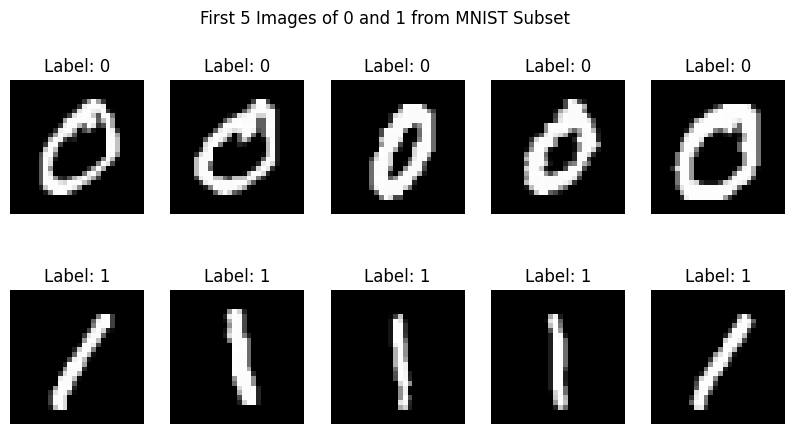

In [ ]:
# Separate images for label 0 and label 1
images_0 = X[y == 0] # Get all images with label 0
images_1 = X[y == 1] # Get all images with label 1
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
# Check if the arrays have the required amount of data
if len(images_0) < 5 or len(images_1) < 5:
  print("Error: Not enough images in images_0 or images_1 to plot 5 images.")
else:
  for i in range(5):
    # Plot digit 0
    axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
    axes[0, i].set_title("Label: 0")
    axes[0, i].axis("off")
    # Plot digit 1
    axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
    axes[1, i].set_title("Label: 1")
    axes[1, i].axis("off")
  plt.suptitle("First 5 Images of 0 and 1 from MNIST Subset")
  plt.show()

In [ ]:
# Initialize weights and bias
weights = np.zeros(X.shape[1]) # 784 weights (one for each pixel)
bias = 0
learning_rate = 0.1
epochs = 100

In [ ]:
import numpy as np
def decision_function(X, weights, bias):
  """
  Compute the predicted labels for the input data.
  Parameters:
  - X: Features (input data) as a numpy array of shape (n_samples, n_features)
  - weights: Updated weights after training
  - bias: Updated bias after training
  Returns:
  - y_pred_all: The predicted labels for the input data
  """
  predictions = np.dot(X, weights) + bias
  #####Your Code Here############ # Activation function (step function)
  return y_pred_all

In [ ]:
import numpy as np

def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    """
    Train the perceptron using the Perceptron Learning Algorithm.
    Parameters:
  - X: Features (input data) as a numpy array of shape (n_samples, n_features)
  - y: Labels (true output) as a numpy array of shape (n_samples,)
  - weights: Initial weights as a numpy array of shape (n_features,)
  - bias: Initial bias value (scalar)
  - learning_rate: Learning rate for weight updates (default is 0.1)
  - epochs: Number of iterations to train the model (default is 100)
    Returns:
  - weights: Updated weights after training
  - bias: Updated bias after training
  - accuracy: Total correct prediction.
      """

    for epoch in range(epochs):
        for i in range(len(X)):
            # Step 1: Linear combination
            output = np.dot(X[i], weights) + bias

            # Step 2: Activation (step function)
            prediction = 1 if output >= 0 else 0

            # Step 3: Update if wrong
            if prediction != y[i]:
                weights = weights + learning_rate * (y[i] - prediction) * X[i]
                bias = bias + learning_rate * (y[i] - prediction)

    # Calculate accuracy
    correct = 0
    for i in range(len(X)):
        output = np.dot(X[i], weights) + bias
        prediction = 1 if output >= 0 else 0
        if prediction == y[i]:
            correct += 1

    accuracy = correct / len(X)

    return weights, bias, accuracy

In [ ]:
# After training the model with the perceptron_learning_algorithm
weights, bias, accuracy = train_perceptron(X, y, weights, bias)
# Evaluate the model using the new function
print("The Final Accuracy is: ", accuracy)

The Final Accuracy is:  1.0


**Question 5:** What is the purpose of the output = np.dot(X[i], weights) + bias line?

-> The line output = np.dot(X[i], weights) + bias calculates the weighted sum of the input features and adds the bias. This gives a single value that helps the perceptron decide whether the output should be 0 or 1.

**question 6:** What happens when the prediction is wrong? How are the weights and
bias updated?

-> When the prediction is wrong, the perceptron updates its weights and bias to reduce the error. It increases or decreases them based on the difference between the actual label and the predicted value, helping the model learn from its mistakes.

**Question 7:** Why is the final accuracy important, and what do you expect it to be?

-> Final accuracy is important because it shows how well the model has learned to classify the data. Ideally, for a linearly separable dataset, we expect the accuracy to be very high, often close to or equal to 100%.

Final Accuracy: 0.9869


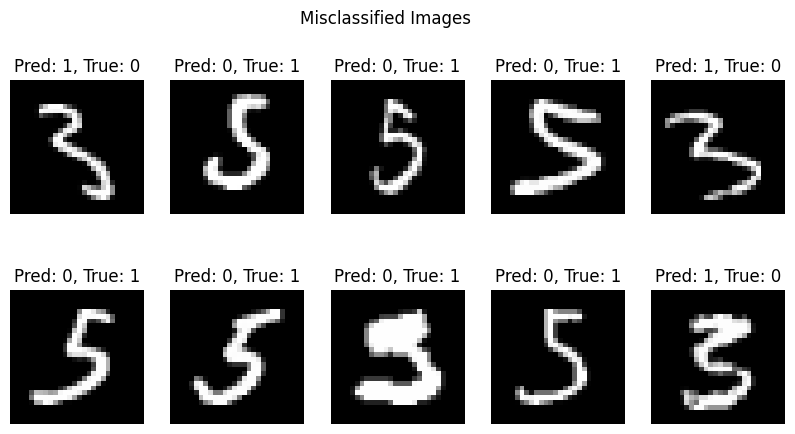

In [ ]:
# Get predictions for all data points
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)
# Calculate final accuracy
final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")
# Step 5: Visualize Misclassified Images
misclassified_idx = np.where(y_pred != y)[0]
if len(misclassified_idx) > 0:
  fig, axes = plt.subplots(2, 5, figsize=(10, 5))
  for ax, idx in zip(axes.flat, misclassified_idx[:10]): # Show 10 misclassified images
    ax.imshow(X[idx].reshape(28, 28), cmap="gray")
    ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
    ax.axis("off")
  plt.suptitle("Misclassified Images")
  plt.show()
else:
  print("All images were correctly classified!")

**Question 8:** What does misclassified idx store, and how is it used in this code?

-> misclassified_idx stores the indices of all the data points where the model’s prediction does not match the actual label. It is used to find and display those specific images so we can visually see where the model made mistakes.

**Question 9:** How do you interpret the result if the output is ”All images were correctly classified!”?

-> If the output says “All images were correctly classified!”, it means the model predicted every sample correctly, resulting in 100% accuracy. This usually indicates that the data is simple or linearly separable, and the perceptron was able to learn it perfectly.

Task 3: Perceptron Algorithm for 3 vs 5 Classification.

In [ ]:
import pandas as pd
import numpy as np

# Load the dataset
df_3_5 = pd.read_csv("/content/drive/MyDrive/Ai and machine learning/mnist_3_and_5.csv")  # Change path if necessary

# Extract features and labels
X = df_3_5.drop(columns=["label"]).values  # 784 pixels
y = df_3_5["label"].values  # Labels 3 or 5

# Optional: Convert labels to binary (3 → 0, 5 → 1) for perceptron
y = np.where(y == 3, 0, 1)

print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)

Feature matrix shape: (2741, 784)
Label vector shape: (2741,)


In [ ]:
n_features = X.shape[1]
weights = np.zeros(n_features)
bias = 0.0

In [ ]:
weights, bias, accuracy = train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100)
print(f"Final Accuracy: {accuracy:.4f}")

Final Accuracy: 0.9869


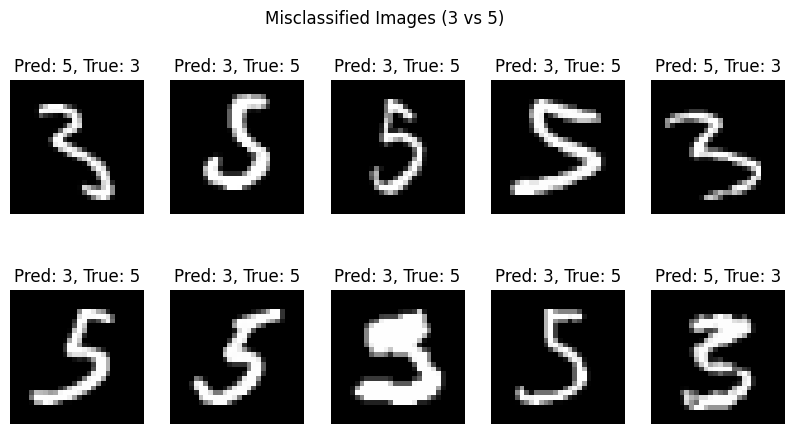

In [ ]:
import matplotlib.pyplot as plt

# Predictions
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)

# Find misclassified images
misclassified_idx = np.where(y_pred != y)[0]

if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx[:10]):  # Show first 10 misclassified images
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")

        # Convert back to original labels (3 or 5)
        true_label = 3 if y[idx] == 0 else 5
        pred_label = 3 if y_pred[idx] == 0 else 5

        ax.set_title(f"Pred: {pred_label}, True: {true_label}")
        ax.axis("off")
    plt.suptitle("Misclassified Images (3 vs 5)")
    plt.show()
else:
    print("All images were correctly classified!")

**Conclusion:**

In the 3 vs 5 classification task, the perceptron was able to learn some patterns distinguishing the two digits, but it struggled with certain images because 3 and 5 are visually more similar than 0 and 1. The misclassified images highlight where the model failed, showing that a single-layer perceptron has limited capacity for more complex or subtle differences. This demonstrates that while perceptrons can handle simple, linearly separable tasks, more advanced models, such as multi-layer neural networks, are needed for higher accuracy on harder digit classification problems.